In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [7]:
#importamos librerías para el preprocesamiento de datos

import warnings 
warnings.filterwarnings('ignore', category=FutureWarning)

# FASE 3 VISUALIZACIÓN 

En este jupyter se realiza la fase 3 que consiste en realizar visualizaciones de las distintas columnas del csv para ver las relaciones entre diferentes valores. También incluye conclusiones de cada visualización. 

In [8]:
#CARGAMOS EL DATASET LIMPIO 
df = pd.read_csv("files/df_unido_limpio.csv")
df.head()

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,canceled_loyalty_card
0,100018,2017,1,3,0,3,1521,152.0,0,0,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,0
1,100102,2017,1,10,4,14,2030,203.0,0,0,Ontario,Toronto,M1R 4K3,Male,College,66888.5,Single,Nova,2887.74,Standard,2013,3,NaN,NaN,0
2,100140,2017,1,6,0,6,1200,120.0,0,0,British Columbia,Dawson Creek,U5I 4F1,Female,College,66888.5,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN,0
3,100214,2017,1,0,0,0,0,0.0,0,0,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN,0
4,100272,2017,1,0,0,0,0,0.0,0,0,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN,0


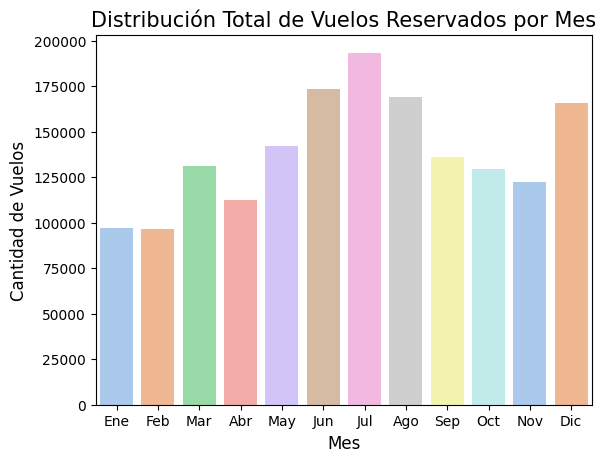

In [34]:
# 1. ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

# Agrupamos por mes y sumamos los vuelos reservados
# Usamos el dataframe limpio que ya tienes
vuelos_por_mes = df.groupby('month')['flights_booked'].sum().reset_index()

# Creamos el gráfico de barras
sns.barplot(data=vuelos_por_mes, x='month', y='flights_booked', palette='pastel')

# Añadimos detalles estéticos
plt.title('Distribución Total de Vuelos Reservados por Mes', fontsize=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad de Vuelos', fontsize=12)
plt.xticks(range(0, 12), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])

plt.show();


CONCLUSIÓN: 
Los meses con peor tiempo y sin vacaciones tienen valores de vuelo más bajos. Cuando las fechas coinciden con vacaciones (Pascua, verano y Navidad) el número de vuelos aumenta. En los meses después de verano hay una bajada según el tiempo empeora aunque luego hay un pico por Navidad. Esto sugiere que el comportamiento de los clientes está fuertemente ligado a periodos vacacionales. 

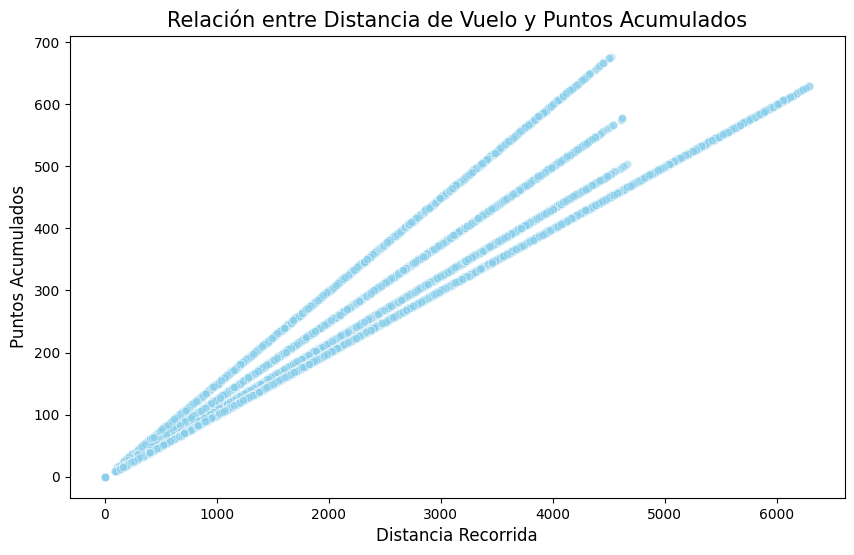

In [33]:
# 2. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?

plt.figure(figsize=(10, 6))

# Usamos un scatter plot para ver la relación
# Usamos 'alpha' para que los puntos sean algo transparentes (hay muchos datos)
sns.scatterplot(data=df, x='distance', y='points_accumulated', alpha=0.5, color='skyblue')

plt.title('Relación entre Distancia de Vuelo y Puntos Acumulados', fontsize=15)
plt.xlabel('Distancia Recorrida', fontsize=12)
plt.ylabel('Puntos Acumulados', fontsize=12)

plt.show();

CONCLUSIÓN:
En la fase 2 del análisis se ha observado que hay una correlacción entre la distancia y los puntos acumulados. Esta gráfica lo confirma ya que hay una relación entre ambas variables que se considera positiva muy fuerte. A los clientes se le dan puntos según la distancia que recorra los vuelos que hayan reservado. 

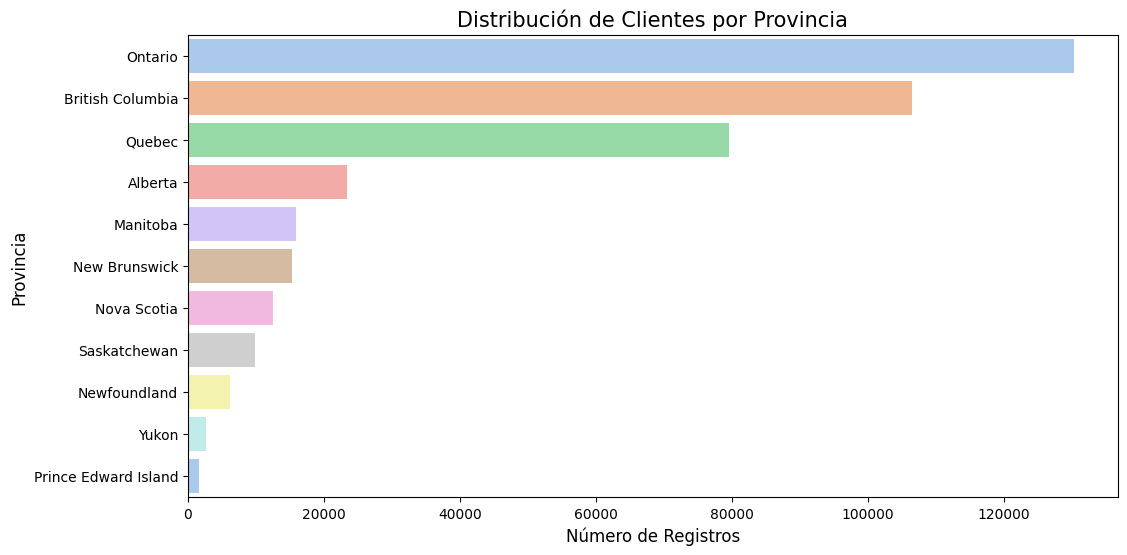

In [31]:
 # 3. ¿Cuál es la distribución de los clientes por provincia o estado?

plt.figure(figsize=(12, 6))

# Calculamos el orden de las provincias por cantidad de clientes (de mayor a menor)
orden_provincias = df['province'].value_counts().index

# Creamos el gráfico de barras
sns.countplot(data=df, y='province', order=orden_provincias, palette='pastel')

# Añadimos detalles estéticos
plt.title('Distribución de Clientes por Provincia', fontsize=15)
plt.xlabel('Número de Registros', fontsize=12)
plt.ylabel('Provincia', fontsize=12)

plt.show()

CONCLUSIÓN: 
Las tres provincias que destacan con más registros son Ontario, Columbia Británica y Quebec. Estas provincias son también las más pobladas. El resto de provincias tienen datos menores de registros. Y Yukon y Prince Edward Island apenas tiene presencia. 

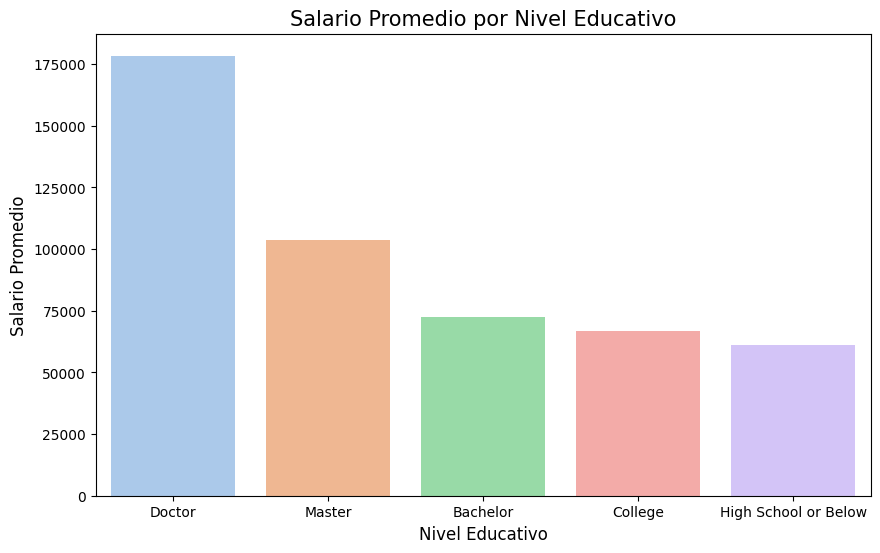

In [30]:
# 4. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?

plt.figure(figsize=(10, 6))

# Calculamos el salario promedio por nivel educativo para ordenar las barras
# Esto ayuda a que el gráfico sea más fácil de leer
orden_educacion = df.groupby('education')['salary'].mean().sort_values(ascending=False).index

# Creamos el gráfico de barras con el promedio
sns.barplot(data=df, x='education', y='salary', order=orden_educacion, palette='pastel', errorbar=None)

# Añadimos detalles estéticos
plt.title('Salario Promedio por Nivel Educativo', fontsize=15)
plt.xlabel('Nivel Educativo', fontsize=12)
plt.ylabel('Salario Promedio', fontsize=12)

plt.show()

Se observa una relación directa entre el nivel de estudios y el salario promedio. Los clientes con Doctorado y Máster presentan los ingresos más altos.
Es relevante destacar que el grupo College presenta un salario promedio competitivo, lo cual valida la estrategia de imputación de nulos realizada en la Fase 1. 

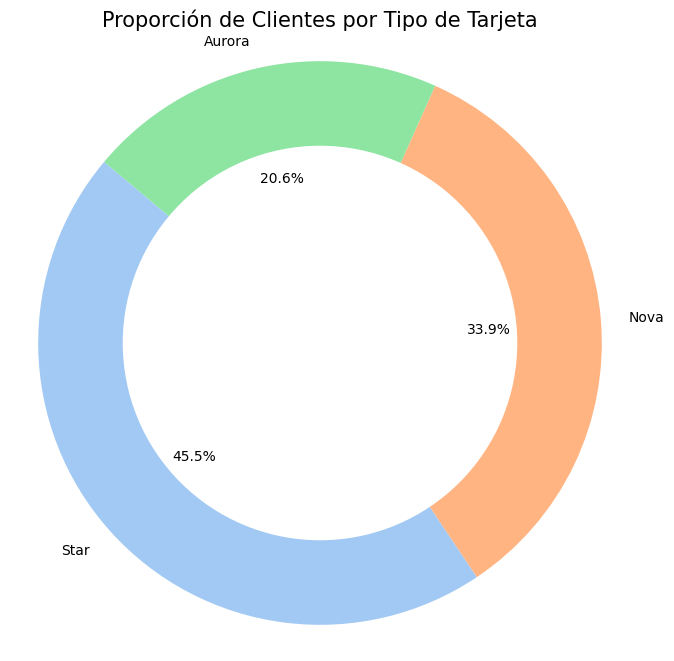

In [23]:
# 5. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

plt.figure(figsize=(8, 8))

# 1. Preparamos los datos (conteo de cada tarjeta)
data_tarjetas = df['loyalty_card'].value_counts()

# 2. Definimos colores que peguen con una aerolínea (azules/dorados)
colores = sns.color_palette('pastel')[0:3]

# 3. Creamos el gráfico de tarta
plt.pie(data_tarjetas, 
        labels = data_tarjetas.index, 
        autopct='%1.1f%%', # Esto pone el porcentaje con un decimal
        startangle=140,    # Gira el gráfico para que se vea mejor
        colors=colores) # Saca un poco la porción más grande para resaltarla

# 4. Lo convertimos en un "Donut" (opcional, pero queda más moderno)
centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

plt.title('Proporción de Clientes por Tipo de Tarjeta', fontsize=15)
plt.axis('equal') # Para que el círculo no salga ovalado

plt.show()

CONCLUSIÓN: 
El programa de fidelidad está liderado por la tarjeta Star, que representa casi la mitad de la base de datos (45.5%). Esto indica que la mayoría de los usuarios se encuentran en el nivel de entrada del programa. La tarjeta Aurora, que presumiblemente es el nivel más exclusivo, cuenta con un 20.6% de los clientes.

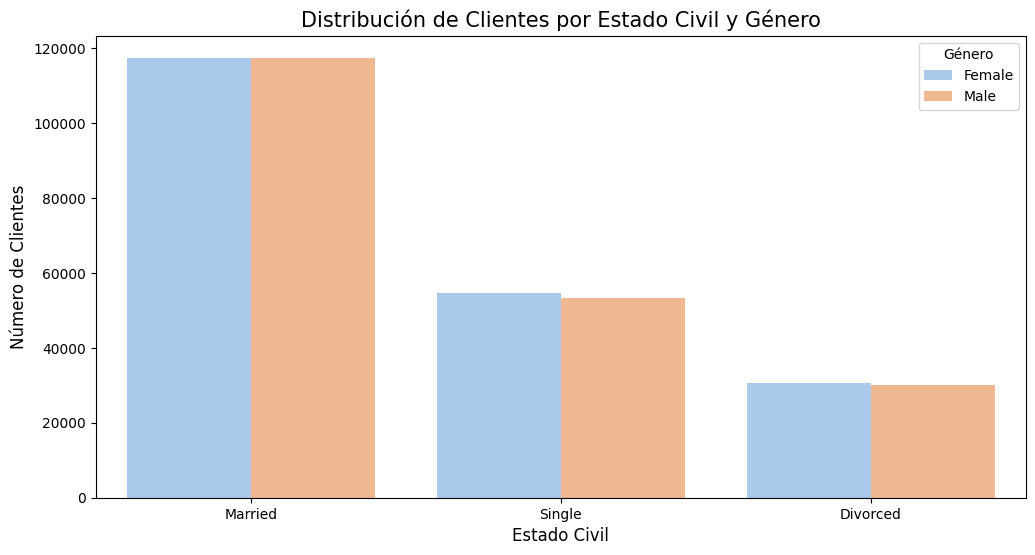

In [29]:
# 6. ¿Cómo se distribuyen los clientes según su estado civil y género?

plt.figure(figsize=(12, 6))

# Usamos countplot con el parámetro 'hue' para separar por género
sns.countplot(data=df, x='marital_status', hue='gender', palette='pastel')

# Añadimos detalles estéticos
plt.title('Distribución de Clientes por Estado Civil y Género', fontsize=15)
plt.xlabel('Estado Civil', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.legend(title='Género')

plt.show()

CONCLUSION: 
La distribución de género es extremadamente equilibrada en todas las categorías de estado civil. No se observan sesgos significativos: tanto en el grupo de personas casadas (el más numeroso) como en el de solteros o divorciados, la proporción de hombres y mujeres es prácticamente del 50%